In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch 
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn 
import torch.optim as optim 
import matplotlib.pyplot as plt

In [39]:
df = pd.read_csv("./dataset/fmnist_small.csv")

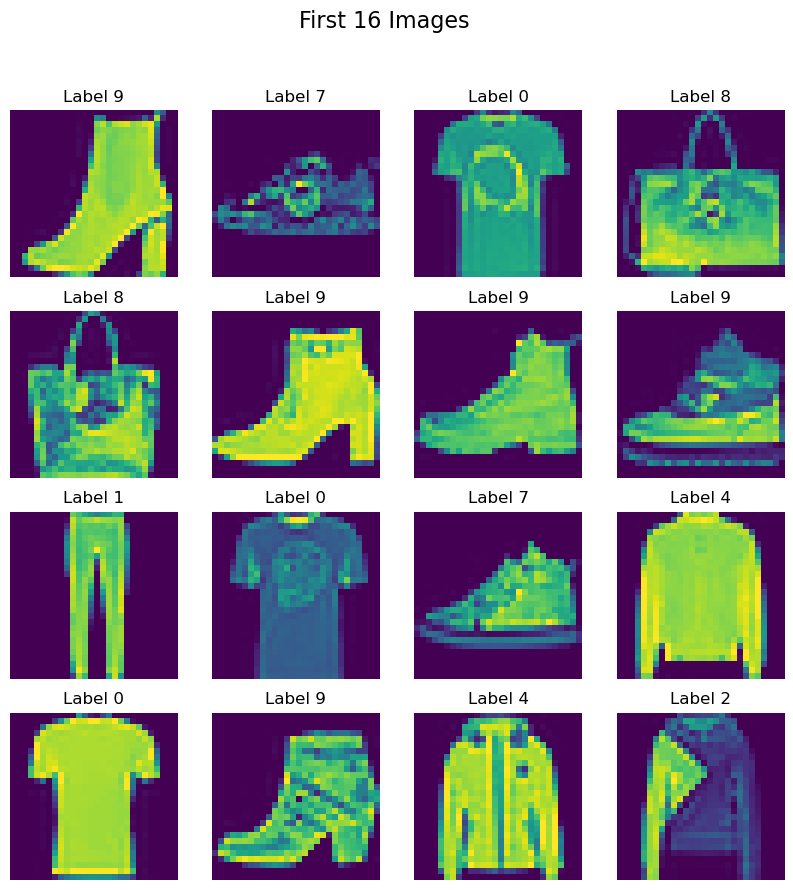

In [40]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label {df.iloc[i,0]}")

In [41]:
# number of input layer -> 28*28 = 784
print(len(df.columns) - 1)

784


In [42]:
# number of output layer -> 10
len(df['label'].unique())

10

Train Test Split

In [43]:
X = df.iloc[:, 1:].values 
y = df.iloc[:, 0].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scaling the features

In [44]:
X_train = X_train/255.0
X_test = X_test/255.0

Custom Dataset

In [45]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long) 

    def __len__(self):
        return len(self.features) 
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [46]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [47]:
len(train_dataset)

4800

In [48]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Define NN Class

In [49]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, X):
        return self.model(X)

Instantiate Model

In [50]:
epochs = 10
learning_rate = 0.1

In [51]:
model = MyNN(X_train.shape[1])

In [52]:
# loss function
criterion = nn.CrossEntropyLoss()

In [53]:
model.parameters()

<generator object Module.parameters at 0x7014559380>

In [54]:
# optimizers
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

Training Loop

In [56]:
for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:
        
        # forward pass
        output = model(batch_features)
        # claculate loss
        loss = criterion(output, batch_labels)
        # back pass
        optimizer.zero_grad()
        loss.backward()
        # update
        optimizer.step()

        total_epoch_loss += loss.item()

avg_loss = total_epoch_loss / len(train_loader)
print(avg_loss)

        


0.2639698439836502


Evaluation

In [60]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        print(f"Predicted: {predicted}")

        # total 
        total = total + batch_labels.shape[0]

        correct += (predicted==batch_labels).sum().item()

print(f"TOtal number is {total}")
print(f"TOtal number of correct is {correct}")
print(correct/total)

Predicted: tensor([7, 0, 5, 6, 3, 2, 5, 4, 9, 7, 0, 6, 4, 0, 5, 1, 7, 5, 6, 0, 4, 0, 2, 0,
        9, 6, 9, 4, 0, 1, 5, 6])
Predicted: tensor([4, 8, 1, 6, 9, 3, 9, 6, 8, 5, 3, 1, 2, 3, 8, 9, 9, 9, 5, 0, 4, 0, 3, 4,
        1, 4, 8, 4, 2, 3, 0, 8])
Predicted: tensor([0, 1, 4, 1, 4, 7, 6, 8, 2, 1, 8, 2, 3, 2, 4, 9, 1, 3, 7, 9, 4, 6, 4, 7,
        0, 4, 1, 3, 4, 1, 6, 6])
Predicted: tensor([8, 3, 7, 1, 6, 5, 4, 2, 8, 9, 8, 5, 6, 5, 2, 3, 7, 9, 9, 7, 1, 6, 6, 6,
        1, 7, 1, 5, 7, 2, 0, 5])
Predicted: tensor([6, 3, 5, 7, 9, 1, 9, 1, 5, 7, 1, 1, 5, 0, 1, 1, 9, 8, 0, 3, 3, 9, 8, 9,
        4, 4, 2, 6, 2, 4, 5, 2])
Predicted: tensor([3, 4, 5, 4, 8, 4, 3, 8, 5, 9, 2, 2, 6, 4, 1, 5, 9, 9, 8, 5, 9, 6, 4, 5,
        0, 9, 1, 2, 4, 1, 4, 6])
Predicted: tensor([4, 3, 6, 8, 3, 3, 3, 3, 4, 6, 1, 2, 7, 7, 0, 9, 1, 3, 2, 7, 9, 6, 2, 0,
        3, 3, 9, 7, 4, 9, 0, 3])
Predicted: tensor([7, 1, 6, 9, 9, 0, 5, 1, 7, 0, 8, 2, 7, 0, 9, 3, 3, 7, 6, 2, 3, 5, 9, 4,
        4, 3, 4, 3, 1, 2, 2, 9])
Predicte